# Load Libraries

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv

load_dotenv()
raw_path = os.getenv("RAW_DATA_PATH")

# Load Data

In [28]:
df = pd.read_csv(raw_path)

In [16]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [17]:
df.shape

(8950, 18)

# Missing Values and dtypes

In [23]:
df.info()
print("\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

# Summary Statistics

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


# Skew, Numerically

In [20]:
numeric_df = df.drop(columns=["CUST_ID"])
skew = numeric_df.skew().sort_values(ascending=False)
skew

MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64

# Data Visualize Distribution

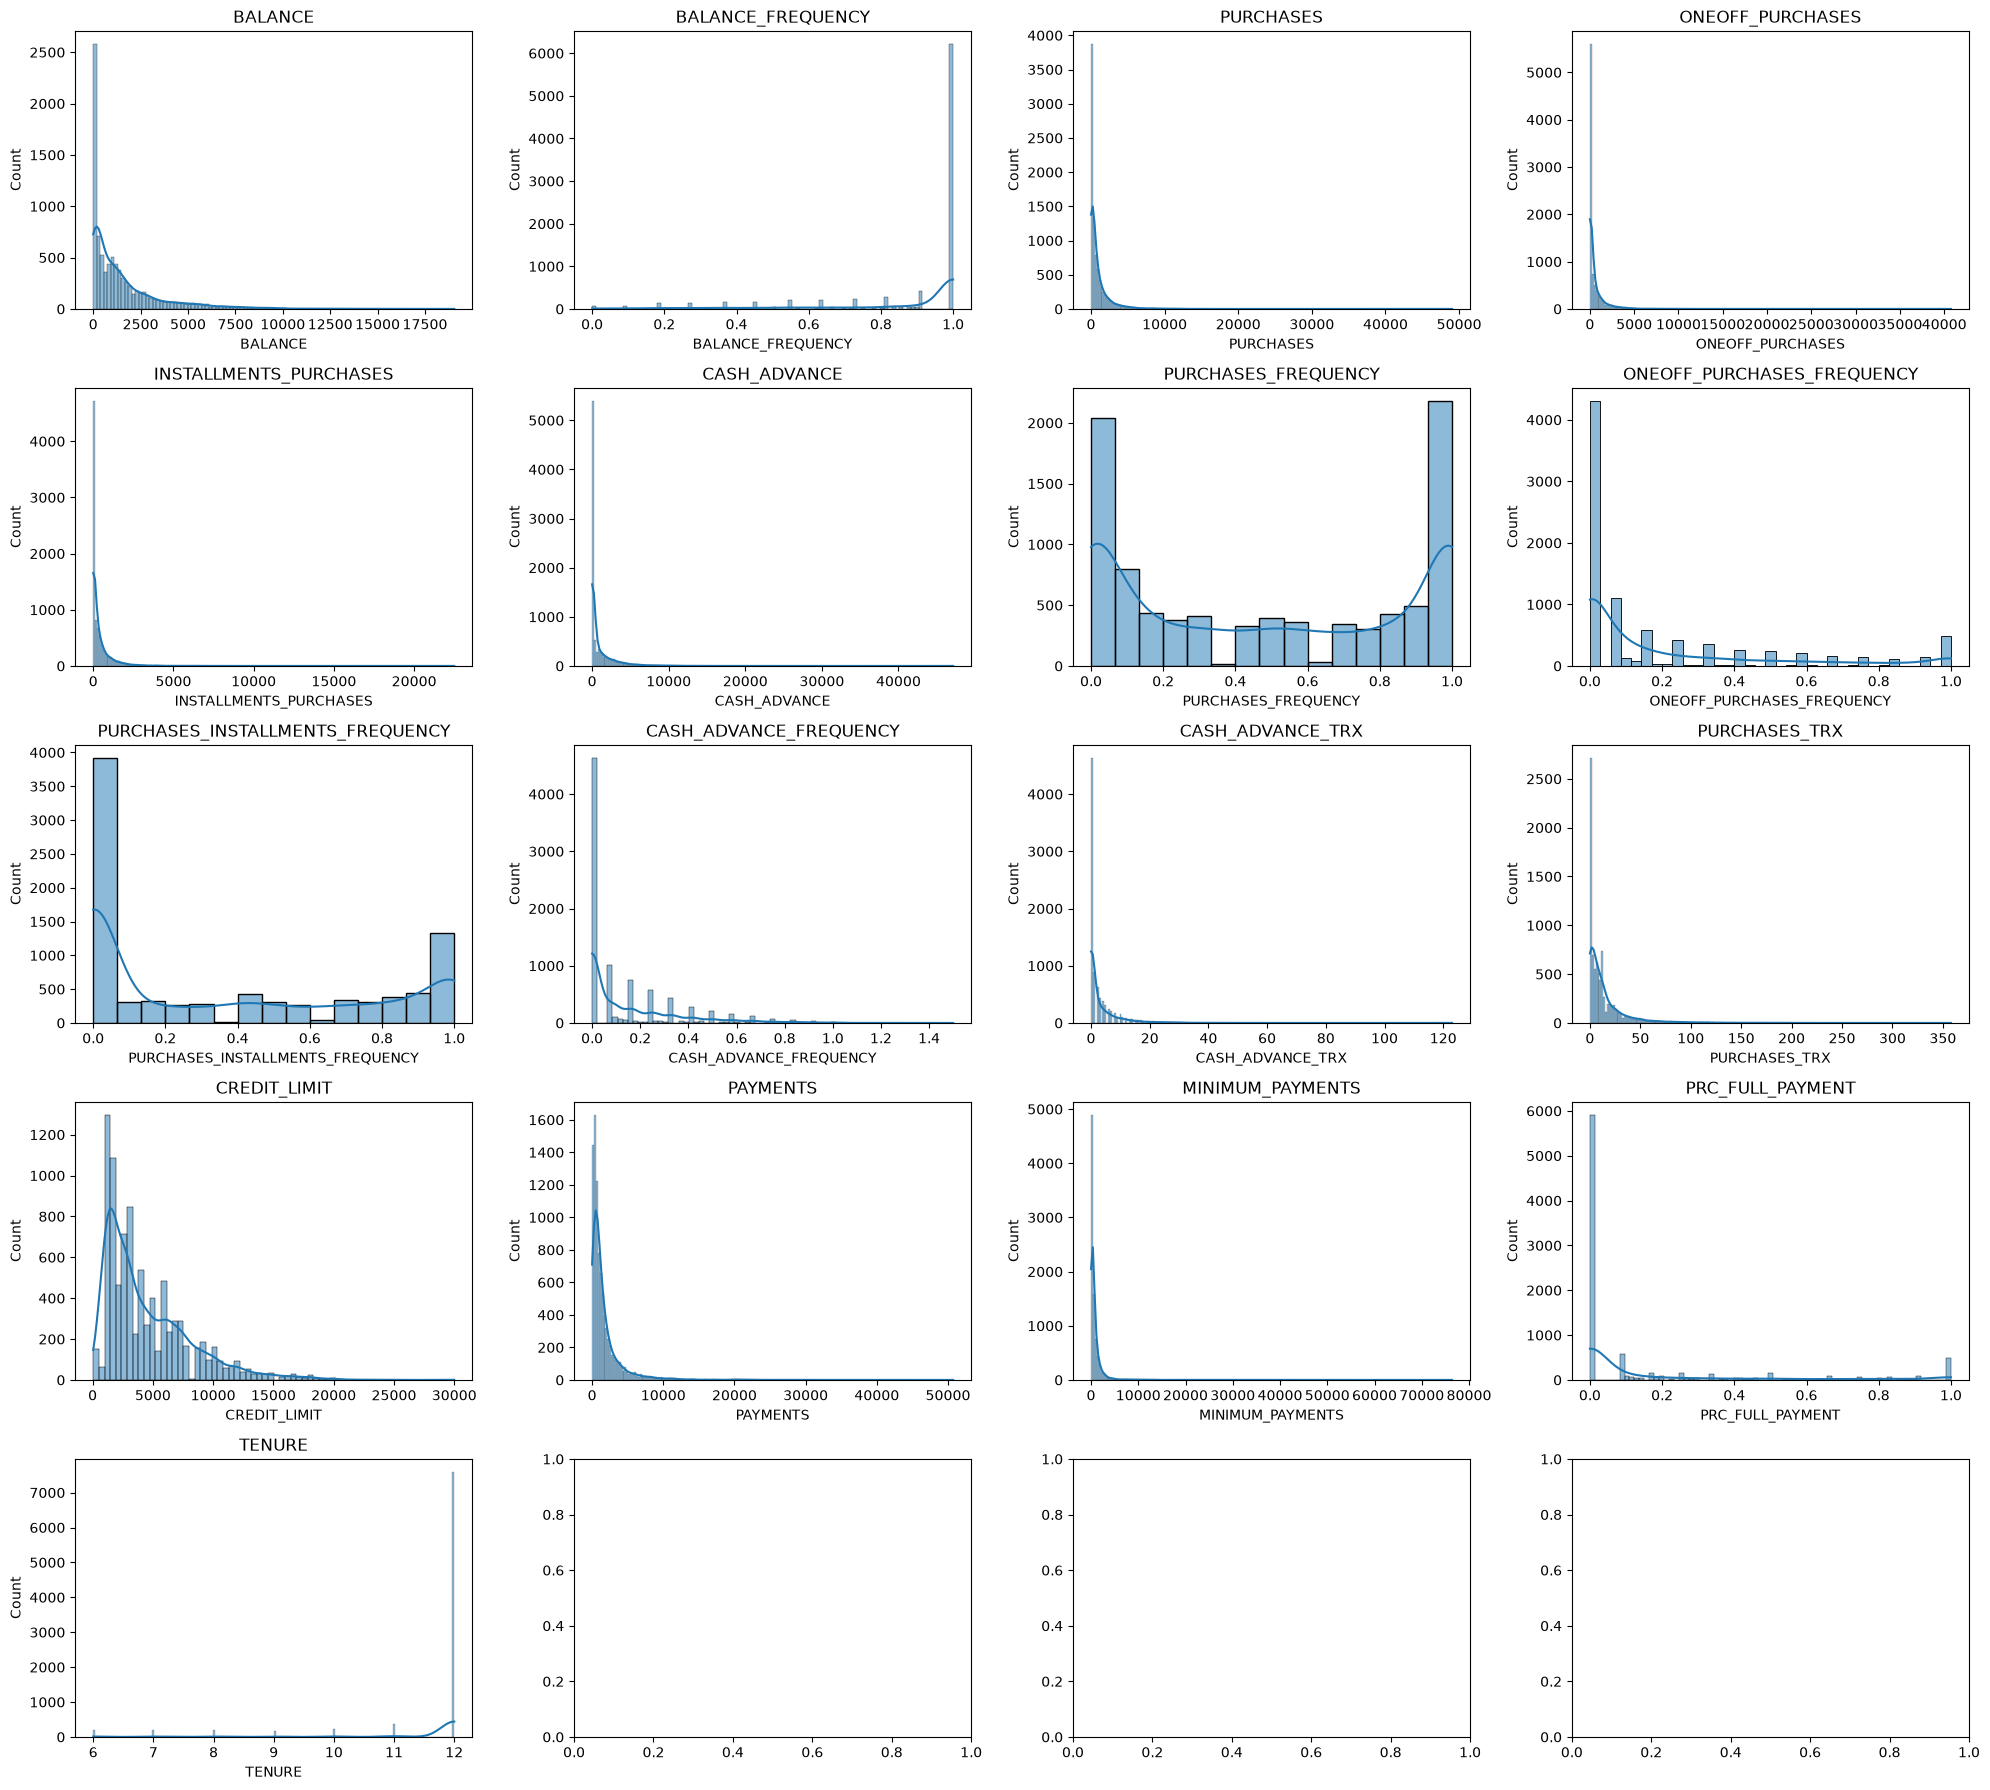

In [21]:
fig, axes = plt.subplots(5, 4, figsize=(20, 18))
for ax, col in zip(axes.flatten(), numeric_df.columns):
    sns.histplot(numeric_df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# Correlation Heatmap

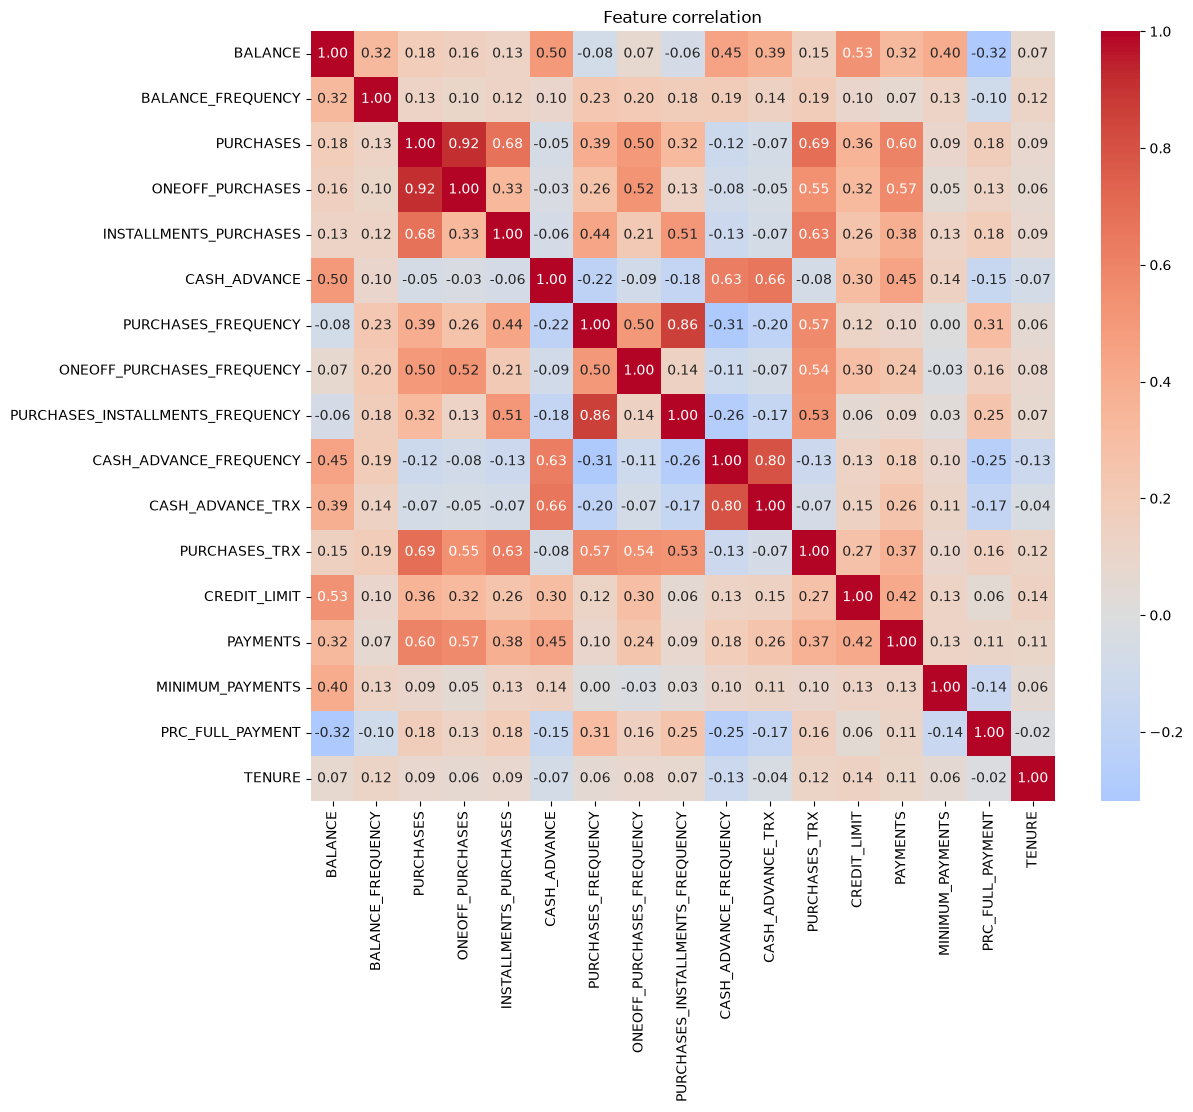

In [22]:
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation")
plt.show()

## EDA observations

**Shape & completeness**
- 8,950 customers, 17 numeric behavioral features (+ `CUST_ID`, dropped before modeling).
- Two columns have missing values: `CREDIT_LIMIT` (1 missing) and `MINIMUM_PAYMENTS` (313 missing, ~3.5%). Both will be median-imputed in `data_transformation.py`.

**Skew — which columns need a log transform**

Skew > 1 is the threshold I'm using to flag a column as needing `log1p` before scaling. By that cutoff:

| Skew > 1 (needs log transform) | Skew < 1 (leave as-is) |
|---|---|
| MINIMUM_PAYMENTS (13.6) | PURCHASES_INSTALLMENTS_FREQUENCY (0.51) |
| ONEOFF_PURCHASES (10.0) | PURCHASES_FREQUENCY (0.06) |
| PURCHASES (8.1) | BALANCE_FREQUENCY (-2.02, left-skewed) |
| INSTALLMENTS_PURCHASES (7.3) | TENURE (-2.94, left-skewed) |
| PAYMENTS (5.9) | |
| CASH_ADVANCE_TRX (5.7) | |
| CASH_ADVANCE (5.2) | |
| PURCHASES_TRX (4.6) | |
| BALANCE (2.4) | |
| PRC_FULL_PAYMENT (1.9) | |
| CASH_ADVANCE_FREQUENCY (1.8) | |
| ONEOFF_PURCHASES_FREQUENCY (1.5) | |
| CREDIT_LIMIT (1.5) | |

All the monetary/count columns are heavily right-skewed — a small number of customers spend or borrow far more than the median, pulling the tail out. This matches the histograms: most distributions show a tall spike near zero and a long thin tail rather than anything bell-shaped.

`BALANCE_FREQUENCY` and `TENURE` are *left*-skewed instead — both are bounded metrics where most customers cluster at the maximum (most people update their balance every cycle; most accounts have the full 12-month tenure). Log transform doesn't apply here since these aren't right-tailed; I'll leave them as-is and let scaling handle them.

**Distribution shapes worth noting**
- The `_FREQUENCY` columns (`PURCHASES_FREQUENCY`, `ONEOFF_PURCHASES_FREQUENCY`, `PURCHASES_INSTALLMENTS_FREQUENCY`, `CASH_ADVANCE_FREQUENCY`) are bounded [0,1] and mostly bimodal — customers cluster near 0 (never do this) or near 1 (always do this), with fewer in between. This is a genuinely different distribution shape than the monetary columns and is useful signal, not noise.
- `TENURE` is almost a spike at 12 — the vast majority of customers have the maximum tenure in this dataset. With so little variance, this column may not contribute much to distinguishing customer segments.
- `CASH_ADVANCE`, `CASH_ADVANCE_TRX`, and `CASH_ADVANCE_FREQUENCY` all show the same pattern: most customers never take a cash advance (spike at zero), and a smaller group does so heavily. This looks like a genuine behavioral split worth preserving as a segment signal.

**Correlation — redundant features to resolve before modeling**

Three pairs exceed 0.8 correlation:
- `PURCHASES` ↔ `ONEOFF_PURCHASES` (0.92) — expected, since one-off purchases are a component of total purchases.
- `PURCHASES_FREQUENCY` ↔ `PURCHASES_INSTALLMENTS_FREQUENCY` (0.86) — frequent purchasers tend to buy via installments.
- `CASH_ADVANCE_FREQUENCY` ↔ `CASH_ADVANCE_TRX` (0.80) — two ways of counting the same cash-advance behavior.

Feeding both members of a highly correlated pair into KMeans effectively double-weights that behavior in the distance calculation. Plan: keep the more granular/informative column from each pair and drop the aggregate, rather than dropping features arbitrarily.

**Decisions carried forward into `config.py`**
1. `SKEWED_COLUMNS` = the 13 columns with skew > 1 listed above — these get `log1p` in `data_transformation.py`.
2. Final `FEATURE_COLUMNS` will exclude one column from each highly-correlated pair (TBD — decide which member of each pair to keep).
3. `TENURE`'s near-zero variance means it may add little to clustering — worth testing with and without it.
4. Missing values in `CREDIT_LIMIT` and `MINIMUM_PAYMENTS` will be median-imputed.